## Jobs Roles & Seniority

This section of the analysis focuses on how job roles & seniorty align with the realities of the data science job market.  
We will explore three key research questions:

### Research Questions
1. **Job Roles & Seniority**  
   - What is the typical job description / requirement pattern for junior vs senior / lead data science roles?
   - How do job postings for data-related jobs change over time (seasonal, yearly, or in response to major tech events)?

---

### Expected Outcomes
- Identify whether the job postings is a strong predictor of change over time.  
- Highlight **changes in requirements needed from data analysts from 2024 to 2025**.  


In [2]:
import pandas as pd 
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the AI job dataset from the datasets folder into a DataFrame called 'seniorjobs'
seniorjobs = pd.read_csv("../datasets/ai_job_dataset.csv")

# Display general information about the dataset:
# number of rows/columns, column names, data types, and non-null counts
seniorjobs.info()

# Generate basic descriptive statistics for numeric columns
# (count, mean, std, min, quartiles, max)
seniorjobs.describe()

# Preview the first 5 rows of the dataset
# This helps confirm the data loaded correctly and shows a sample of the values
seniorjobs.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [9]:
# Check the number of rows and columns in the dataset
seniorjobs.shape

(15000, 19)

In [10]:
# Check how many null (missing) values are present in each column
seniorjobs.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [11]:
# Create a cleaned version of the dataset by dropping rows with missing values
seniorjobs_clean = seniorjobs.dropna()

# Verify that no missing values remain
seniorjobs_clean.isnull().sum().sum()

np.int64(0)

In [ ]:
roles_jobs = seniorjobs_clean[['job_title','posting_date','experience_level', 'education_required', 'years_experience','required_skills']]
print(roles_jobs)


                         job_title posting_date experience_level  \
0            AI Research Scientist   2024-10-18               SE   
1             AI Software Engineer   2024-11-20               EN   
2                    AI Specialist   2025-03-18               MI   
3                     NLP Engineer   2024-12-23               SE   
4                    AI Consultant   2025-04-15               EN   
...                            ...          ...              ...   
14995            Robotics Engineer   2025-02-06               EN   
14996  Machine Learning Researcher   2024-10-16               EN   
14997                 NLP Engineer   2024-03-19               EX   
14998                   Head of AI   2024-03-22               EN   
14999     Computer Vision Engineer   2024-07-18               MI   

      education_required  years_experience  \
0               Bachelor                 9   
1                 Master                 1   
2              Associate                 2   

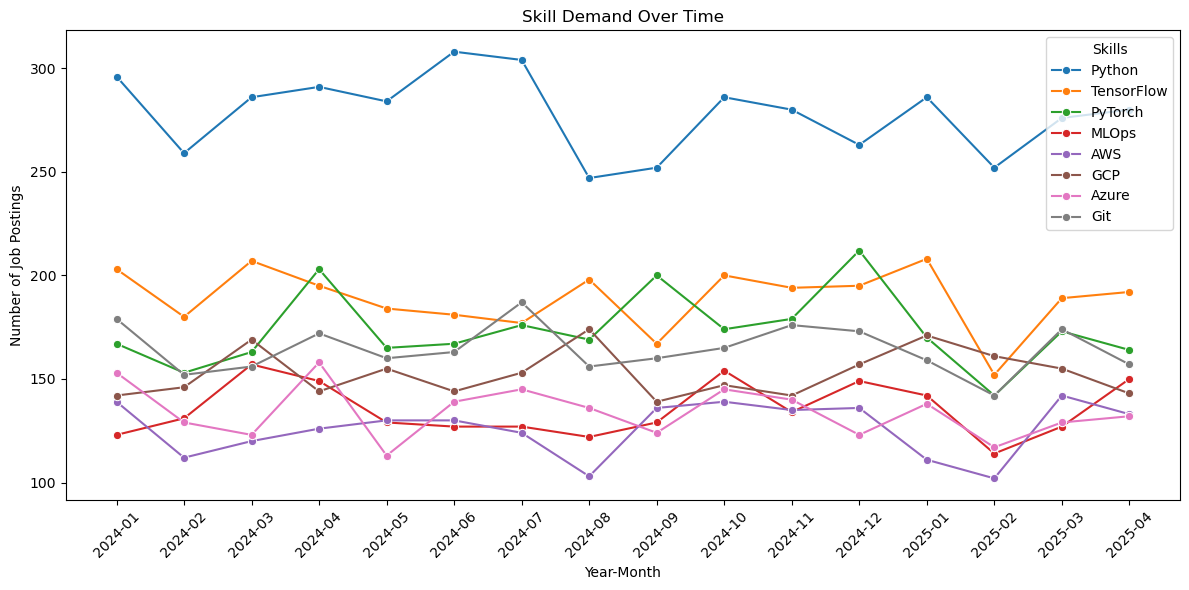

In [27]:
# Skills to track over time
skills_to_track = ['Python', 'TensorFlow', 'PyTorch', 'MLOps', 'AWS', 'GCP', 'Azure', 'Git', 'Generative AI']

# Ensure posting_date is datetime and added a Year-Month key

role_jobs = roles_jobs.copy()
role_jobs['posting_date'] = pd.to_datetime(role_jobs['posting_date'], errors='coerce')
role_jobs['year_month']   = role_jobs['posting_date'].dt.to_period('M').astype(str)


# Build a long table of skill-month counts
records = []
for sk in skills_to_track:
    mask = role_jobs['required_skills'].str.contains(fr'\b{sk}\b', case=False, na=False, regex=True)
    tmp = (role_jobs[mask]
           .groupby("year_month")
           .size()
           .reset_index(name='count'))
    tmp['skill'] = sk
    records.append(tmp)

trend_df = pd.concat(records, ignore_index=True) if records else pd.DataFrame(columns=['year_month','count','skill'])

# Plotting the trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, x='year_month', y='count', hue='skill', marker='o')

# Improving plot aesthetics
plt.title('Skill Demand Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.legend(title='Skills')
plt.tight_layout()
plt.show()
